## Introduction

This notebook presents an unsupervised machine learning analysis using the K-Means Clustering algorithm applied to the classic Iris plant dataset. The primary goal is to assess the algorithm's ability to naturally group the flower samples into their three known species categories based solely on their morphological measurements.

# Import Libralies

In [1]:
# Data Manipulation
import pandas as pd

# Data Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# K-mean Algorithm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

# Read the Data file

In [2]:
def read_file(filepath):
    """reads the data file and shows as a dataframe."""
    df = pd.read_csv(filepath)
    return df

iris = 'iris.data'
df = read_file(iris)
df.sample(8)

,5.1,3.5,1.4,0.2,Iris-setosa
68,5.6,2.5,3.9,1.1,Iris-versicolor
14,5.7,4.4,1.5,0.4,Iris-setosa
72,6.1,2.8,4.7,1.2,Iris-versicolor
132,6.3,2.8,5.1,1.5,Iris-virginica
139,6.7,3.1,5.6,2.4,Iris-virginica
77,6.0,2.9,4.5,1.5,Iris-versicolor
93,5.6,2.7,4.2,1.3,Iris-versicolor
38,5.1,3.4,1.5,0.2,Iris-setosa


## Get overview of the dataset

In [3]:
df.columns

Index(['5.1', '3.5', '1.4', '0.2', 'Iris-setosa'], dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149 entries, 0 to 148
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   5.1          149 non-null    float64
 1   3.5          149 non-null    float64
 2   1.4          149 non-null    float64
 3   0.2          149 non-null    float64
 4   Iris-setosa  149 non-null    object 
dtypes: float64(4), object(1)
memory usage: 5.9+ KB


In [5]:
df.shape

(149, 5)

In [6]:
df.isnull().sum().sum()

0

In [7]:
df.duplicated().sum()

3

## Data Preprocessing

In [8]:
def preprocessing(filepath):
    """cleans the dataset."""

    mapper = {
        0: "sepal_length",
        1: "sepal_width",
        2: "petal_length",
        3: "petal_width",
        4: "species"
    }

    # Read the data file and ADD header=None
    df = pd.read_csv(filepath, header=None)
    
    # drop duplicated rows 
    df = df.drop_duplicates()
    
    # Reset the index after dropping rows
    df = df.reset_index(drop=True) # drop=True prevents the old index from becoming a new column

    # Rename the columns
    df = df.rename(columns=mapper)

    return df

In [9]:
df_iris = preprocessing(iris)
df_iris.sample(5)

,sepal_length,sepal_width,petal_length,petal_width,species
82,5.4,3.0,4.5,1.5,Iris-versicolor
109,6.4,2.7,5.3,1.9,Iris-virginica
18,5.7,3.8,1.7,0.3,Iris-setosa
120,7.7,2.8,6.7,2.0,Iris-virginica
39,4.5,2.3,1.3,0.3,Iris-setosa


In [10]:
df_iris['species'].unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

## K-means Algorithm

## Data Preparation

In [11]:
# Map species to numeric labels
species_mapping = {'Iris-setosa': 0, 'Iris-versicolor': 1, 'Iris-virginica': 2}
y_true = df_iris['species'].map(species_mapping)

# Features only
X = df_iris[['petal_length', 'petal_width']]  # <-- FIX: Use df_iris

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA (reduce to 2 dimensions) - This part is not being used, which is fine!
pca = PCA(n_components=3, random_state=42)
X_pca = X_scaled

## Fit the data

In [12]:
# K-Means clustering with improved parameters
kmeans = KMeans(n_clusters=3, init='k-means++', n_init=200, random_state=42)
kmeans.fit(X_scaled)
y_pred = kmeans.labels_

# Add the cluster labels to your clean DataFrame
df_iris['Cluster'] = y_pred

In [13]:
# Compute Adjusted Rand Index (ARI)
ari_score = adjusted_rand_score(y_true, y_pred) # y_pred is the same as kmeans.labels_
print(f"ARI using only petal features: {ari_score:.4f}")

ARI using only petal features: 0.8823


The Adjusted Rand Index (ARI) of 0.8823 indicates a high degree of agreement between the clusters found by the K-Means algorithm and the true species labels. This is a significant improvement over previous attempts using all four features, demonstrating the effectiveness of feature selection by isolating the most discriminatory variables (petal dimensions).

## Interpretation

In [14]:
# Now this line will work because 'Cluster' exists on df_iris
cluster_analysis = df_iris.groupby('Cluster').mean(numeric_only=True) # <-- FIX: Use df_iris

print(cluster_analysis)

         sepal_length  sepal_width  petal_length  petal_width
Cluster                                                      
0            5.913462     2.738462      4.296154     1.325000
1            6.657447     3.023404      5.576596     2.059574
2            5.010417     3.431250      1.462500     0.250000


## Cluster Interpretation

Cluster Interpretation

The three clusters clearly correspond to the three known species, distinguished primarily by their petal sizes:

1. Cluster 2 (Smallest): Defined by extremely small petals (average length 1.46 cm, width 0.25 cm) and generally small sepals. This cluster clearly represents the Iris-setosa species.

2. Cluster 0 (Medium): Characterized by intermediate petal sizes (average length 4.30 cm, width 1.33 cm). This cluster aligns well with the Iris-versicolor species.

3. Cluster 1 (Largest): Characterized by the largest petal and sepal dimensions (average petal length 5.58 cm, width 2.06 cm). This cluster represents the Iris-virginica species.

## Visualisation

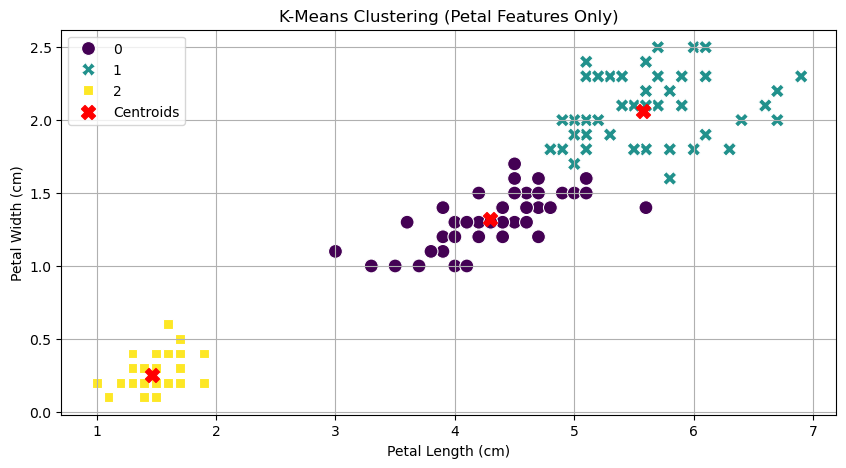

In [15]:
# 1. Add the new, better cluster labels to your main DataFrame
df_iris['Cluster'] = y_pred

# 2. Get the centroid coordinates (in 2D SCALED space)
centroids_scaled = kmeans.cluster_centers_  # Shape is (3, 2)

# 3. Inverse transform the centroids back to the ORIGINAL scale
# This works because your scaler was fit on the 2 petal features
centroids_unscaled = scaler.inverse_transform(centroids_scaled)

# 4. Convert to a DataFrame for easy plotting
# Note: Use the same columns you used for X
centroids_df = pd.DataFrame(centroids_unscaled, columns=['petal_length', 'petal_width'])

# 5. Plot the results
plt.figure(figsize=(10, 5))

# Scatter Plot for Data Points (colored by new cluster)
sns.scatterplot(
    data=df_iris,  # <-- FIX: Use df_iris
    x='petal_length', 
    y='petal_width', 
    hue='Cluster', 
    palette='viridis', 
    style='Cluster',
    s=100, 
    legend='full'
)

# Add Centroids
plt.scatter(
    data=centroids_df,
    x='petal_length',
    y='petal_width',
    marker='X',        
    s=100,             # Make them big
    color='red',     
    label='Centroids'
)

plt.title('K-Means Clustering (Petal Features Only)')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.legend()
plt.grid(True)
plt.show()